In [47]:
#!/home/was966/micromamba/envs/responder/bin/python
#sbatch --mem 64G -c 4 -t 12:00:00 -p gpu_quad --gres=gpu:rtx8000:1 ./01_cohort_to_cohort_transfer.py

import sys

#sys.path.insert(0, '/home/was966/Research/mims-conceptor/')
from compass.utils import plot_embed_with_label
from compass import PreTrainer, FineTuner, loadcompass #, get_minmal_epoch
from compass.utils import plot_embed_with_label, score2
from compass.tokenizer import CANCER_CODE

import os
from tqdm import tqdm
from itertools import chain
import pandas as pd
import numpy as np
import random, torch
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style = 'white', font_scale=1.3)
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

def onehot(S):
    assert type(S) == pd.Series, 'Input type should be pd.Series'
    dfd = pd.get_dummies(S, dummy_na=True)
    nanidx = dfd[dfd[np.nan].astype(bool)].index
    dfd.loc[nanidx, :] = np.nan
    dfd = dfd.drop(columns=[np.nan])*1.
    cols = dfd.sum().sort_values(ascending=False).index.tolist()
    dfd = dfd[cols]
    return dfd

In [48]:
data_path = '../../../paper/00_data/'
df_label = pd.read_pickle(os.path.join(data_path, 'ITRP.PATIENT.TABLE'))
df_tpm = pd.read_pickle(os.path.join(data_path, 'ITRP.TPM.TABLE'))

df_task = onehot(df_label.response_label)
size = df_label.groupby('cohort').size()
size = size.index + "\n(n=" + size.astype(str) + ")"

dfcx = df_label.cancer_type.map(CANCER_CODE).to_frame('cancer_code').join(df_tpm)
dfy = df_task
cohorts = df_label.groupby('cohort').size().sort_values().index.tolist()

size.loc[cohorts]

cohort
Choueiri           Choueiri\n(n=16)
Miao                   Miao\n(n=17)
Snyder               Snyder\n(n=21)
SU2CLC2             SU2CLC2\n(n=25)
Zhao                   Zhao\n(n=25)
Hugo                   Hugo\n(n=26)
MGH                     MGH\n(n=34)
Allen                 Allen\n(n=39)
Kim                     Kim\n(n=45)
Riaz                   Riaz\n(n=51)
Gide                   Gide\n(n=73)
Rose                   Rose\n(n=89)
SU2CLC1            SU2CLC1\n(n=102)
Liu                    Liu\n(n=107)
IMmotion150    IMmotion150\n(n=165)
IMVigor210      IMVigor210\n(n=298)
dtype: object

In [49]:
cohorts = pd.Series(cohorts).map(size).to_list()

## loading bechmarks

In [50]:
from glob import glob
csvs = glob('./baseline_run/baseline_LOPO/LOO_*/*.csv')

res = []
for csv in csvs:
    if 'performance.csv' in csv:
        continue
    df = pd.read_csv(csv, index_col =0)
    df['mode'] = csv.split('/')[-2].split('_')[-1]
    df['cohort'] = size.loc[csv.split('/')[-1].replace('.csv', '')]
    res.append(df)

data1 = pd.concat(res)
data1.head()

,NR,R,0,1,best_C,cohort,mode
Index,,,,,,,
Patient166_T,0.0,1.0,0.526022,0.473978,0.1,Liu\n(n=107),PD1
Patient99_T_P,0.0,1.0,0.494763,0.505237,0.1,Liu\n(n=107),PD1
Patient100_T_P,0.0,1.0,0.461394,0.538606,0.1,Liu\n(n=107),PD1
Patient112_T_P,1.0,0.0,0.468813,0.531187,0.1,Liu\n(n=107),PD1
Patient116_T_P,1.0,0.0,0.488565,0.511435,0.1,Liu\n(n=107),PD1


## loading conceptor

In [51]:
csvs = glob('./conceptor_run/LOO_*_*/*.csv')
res = []
for csv in csvs:
    if 'performance.csv' in csv:
        continue
    df = pd.read_csv(csv, index_col =0)
    df['mode'] = csv.split('/')[-2].split('_')[-2]
    df['cohort'] = size.loc[csv.split('/')[-1].replace('.csv', '')]
    res.append(df)

data2 = pd.concat(res)
data2.head()

,NR,R,0,1,best_epoch,cohort,n_trainable_params,mode,seed,batch_size,task_dense_layer
Index,,,,,,,,,,,
Patient166_T,0.0,1.0,0.438654,0.561346,13.0,Liu\n(n=107),875,LFT,42,16.0,[16]
Patient99_T_P,0.0,1.0,0.022717,0.977283,14.0,Liu\n(n=107),875,LFT,42,16.0,[16]
Patient100_T_P,0.0,1.0,0.495021,0.504979,15.0,Liu\n(n=107),875,LFT,42,16.0,[16]
Patient112_T_P,1.0,0.0,0.239948,0.760052,13.0,Liu\n(n=107),875,LFT,42,16.0,[16]
Patient116_T_P,1.0,0.0,0.785283,0.214717,14.0,Liu\n(n=107),875,LFT,42,16.0,[16]


In [52]:
# from matplotlib.collections import PatchCollection
# import matplotlib.patches as mpatches

# fig,ax = plt.subplots(figsize=(12,6))

# palette = sns.palettes.color_palette('hsv', 3)

# sns.boxplot(data = data2, x = 'cohort', y = 'best_epoch', hue = 'mode', order = cohorts, 
#             hue_order = ['LFT', 'PFT', 'FFT'], palette = palette, fliersize = 0, ax=ax)

# # sns.swarmplot(data = data,  x = 'cohort', y = 'best_epoch', hue = 'mode', order = cohorts,size=1,
# #               palette = palette, alpha = 1, hue_order = ['NFT','LFT', 'PFT', 'FFT'],  edgecolor='k')

# ax.tick_params(axis='both', which='major', right = False, top=False, direction = 'out',reset = True)

# ax.set_xticklabels(
#     cohorts, 
#     rotation=55, 
#     ha="right",  
#     rotation_mode="anchor")  # <====== HERE is the ke

# ax.set_xlabel('Cohort')
# ax.set_ylabel('LOPO Best epoch')
# # ax.set_ylim(0,1)


# fancybox1 = mpatches.FancyBboxPatch(xy = [0, -2.5], width = 4,height =  1, 
#                                    boxstyle=mpatches.BoxStyle("square", pad=1), 
#                                    facecolor='blue',  # 设置框的填充颜色为蓝色 edgecolor='red'
#                                    )
# fancybox2 = mpatches.FancyBboxPatch(xy = [6, -2.5], width = 4, height =  1, 
#                                    boxstyle=mpatches.BoxStyle("square", pad=1), 
#                                    facecolor='green',  # 设置框的填充颜色为蓝色 edgecolor='red'
#                                    )
# fancybox3 = mpatches.FancyBboxPatch(xy = [12, -2.5], width = 3,height =  1, 
#                                    boxstyle=mpatches.BoxStyle("square", pad=1), 
#                                    facecolor='red',  # 设置框的填充颜色为蓝色 edgecolor='red'
#                                    )

# ax.add_patch(fancybox1)
# ax.add_patch(fancybox2)
# ax.add_patch(fancybox3)

# fig.tight_layout()

# fig.savefig('./epochs_distribution.pdf')

## Merge & analysis

In [53]:
data = data2._append(data1)
data = data.reset_index()
data.head()

,Index,NR,R,0,1,best_epoch,cohort,n_trainable_params,mode,seed,batch_size,task_dense_layer,best_C
0,Patient166_T,0.0,1.0,0.438654,0.561346,13.0,Liu\n(n=107),875.0,LFT,42.0,16.0,[16],NaN
1,Patient99_T_P,0.0,1.0,0.022717,0.977283,14.0,Liu\n(n=107),875.0,LFT,42.0,16.0,[16],NaN
2,Patient100_T_P,0.0,1.0,0.495021,0.504979,15.0,Liu\n(n=107),875.0,LFT,42.0,16.0,[16],NaN
3,Patient112_T_P,1.0,0.0,0.239948,0.760052,13.0,Liu\n(n=107),875.0,LFT,42.0,16.0,[16],NaN
4,Patient116_T_P,1.0,0.0,0.785283,0.214717,14.0,Liu\n(n=107),875.0,LFT,42.0,16.0,[16],NaN


In [54]:
dfp = data.groupby(['cohort', 'mode']).apply(lambda x: score2(x['R'], x['1'],
                                                             x[['0', '1']].idxmax(axis=1).astype(int)))
dfp = dfp.apply(pd.Series)
dfp.columns = ['ROC', 'PRC', 'F1', 'ACC','MCC']
dfp = dfp.reset_index()
dfp['size'] = dfp.cohort.apply(lambda x:x.split('n=')[-1].replace(')', ''))
dfp['size'] = dfp['size'].astype(int)
def cohort_size(x):
    if x <= 30:
       s = 'small'
    elif 100 > x > 30:
        s = 'medium'
    elif x > 100:
        s = 'large'
    return s
dfp['size_map'] = dfp['size'].map(cohort_size)
dfp.head()

,cohort,mode,ROC,PRC,F1,ACC,MCC,size,size_map
0,Allen\n(n=39),CAF,0.357988,0.262810,0.370370,0.564103,0.037796,39,medium
1,Allen\n(n=39),CD8,0.579882,0.369362,0.500000,0.641026,0.223607,39,medium
2,Allen\n(n=39),CIS,0.644970,0.413898,0.500000,0.641026,0.223607,39,medium
3,Allen\n(n=39),CKS,0.627219,0.380957,0.482759,0.615385,0.184302,39,medium
4,Allen\n(n=39),CTL,0.627219,0.398782,0.482759,0.615385,0.184302,39,medium


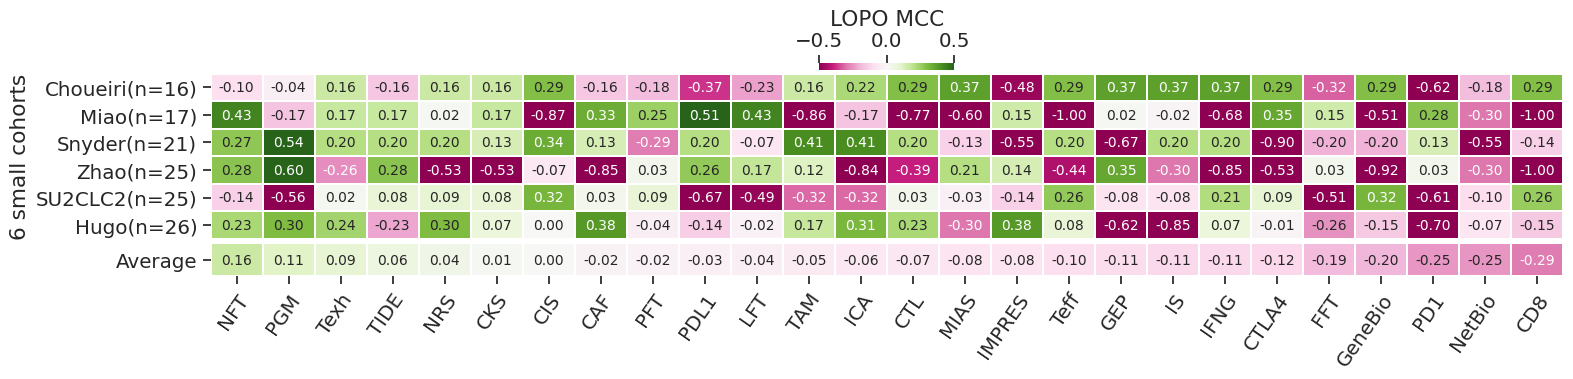

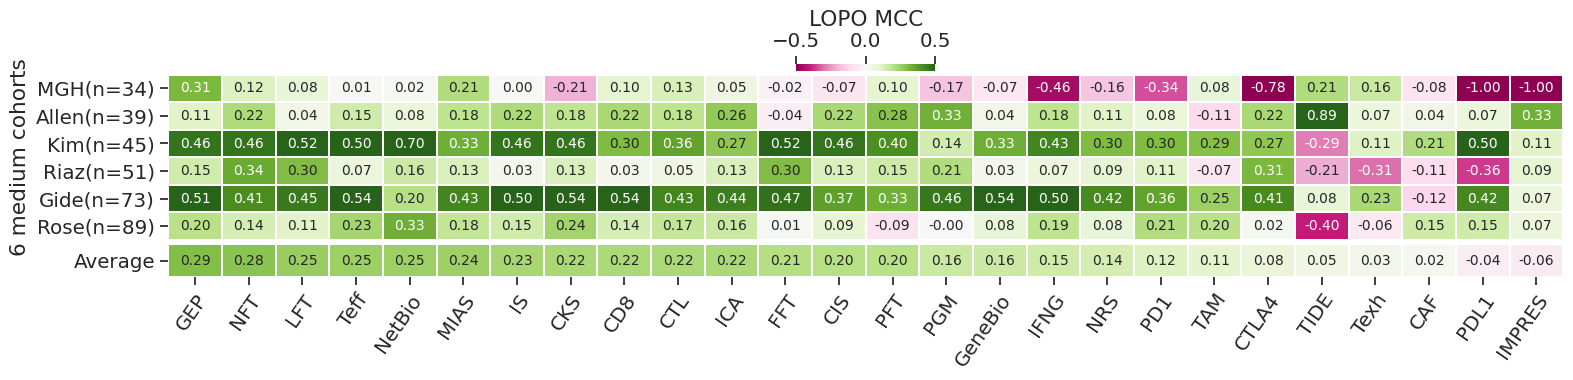

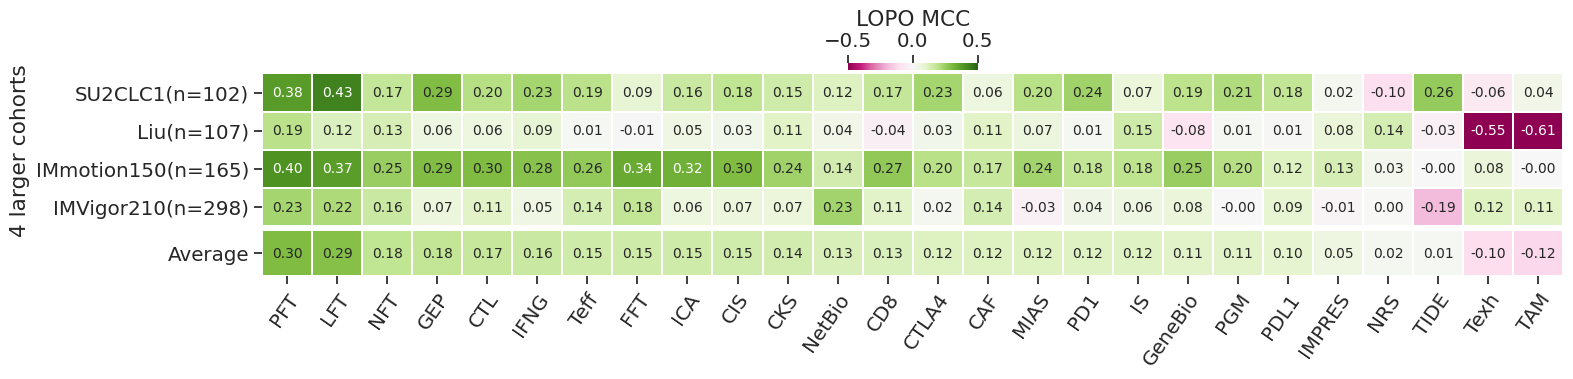

In [55]:
values = 'MCC'
    
cmap = 'PiYG'
vmax = 0.5
vmin = -0.5
labels = ['6 small cohorts',  '6 medium cohorts', '4 larger cohorts'  ]
for s, label in zip(['small', 'medium', 'large'], labels):

    dfp1 = dfp[dfp['size_map'] == s]
    dfp1['cohort_name'] = dfp1['cohort'].apply(lambda x:x.replace('\n', ''))
    
    y_order = dfp1.sort_values('size')['cohort_name'].unique()
    data2d = pd.pivot_table(dfp1, index='mode', columns = 'cohort_name', values = values)
    modes = dfp1.groupby('mode')[values].mean().sort_values(ascending=False).index.to_list()
    data2d = data2d[y_order]
    data2d = data2d.loc[modes].T

    
    fig,axes = plt.subplots(figsize=(16, 4), nrows=2, height_ratios = [len(y_order), 1], sharex=True)
    ax1, ax2 = axes  


    cbar_kws=dict(location="top",pad=0.02,shrink=0.1, label = 'LOPO %s' % values)
    sns.heatmap(data2d, cmap = cmap, vmax = vmax, vmin = vmin, ax=ax1, cbar_kws = cbar_kws,
                fmt='.2f',   linewidths = 0.1, annot=True, annot_kws = {'fontsize':10})

    sns.heatmap(data2d.mean().to_frame(name='Average').T, 
                                        cmap = cmap, vmax = vmax, vmin = vmin,
                                        ax=ax2, annot=True, linewidths=.1, fmt='.2f',
                                        annot_kws={"fontsize":10}, cbar=False)
    
    ax1.set_xlabel('')
    ax1.set_ylabel(label)
    
    ax2.tick_params(axis='both', which='major', right = False, top=False, direction = 'out',reset = True)
    ax1.tick_params(axis='y', which='major', right = False, top=False, direction = 'out',reset = True)
    
    ax2.set_xticklabels(
        modes, 
        rotation=55, 
        ha="right",  
        rotation_mode="anchor")  # <====== HERE is the ke
    
    #plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.06, hspace=None)
    ax2.set_xlabel('')
    
    fig.tight_layout(h_pad = 0.2)
    #fig.savefig('./results/%s_%s.pdf' % (values, s), bbox_inches = 'tight', dpi= 96 )
    fig.savefig('./results/%s_%s.svg' % (values, s), bbox_inches = 'tight', dpi= 96 )

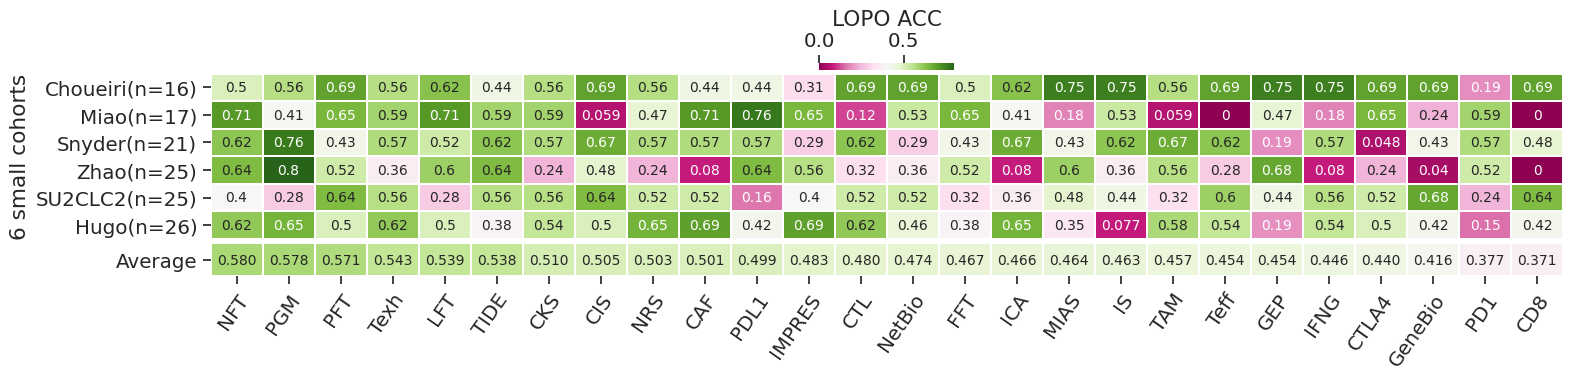

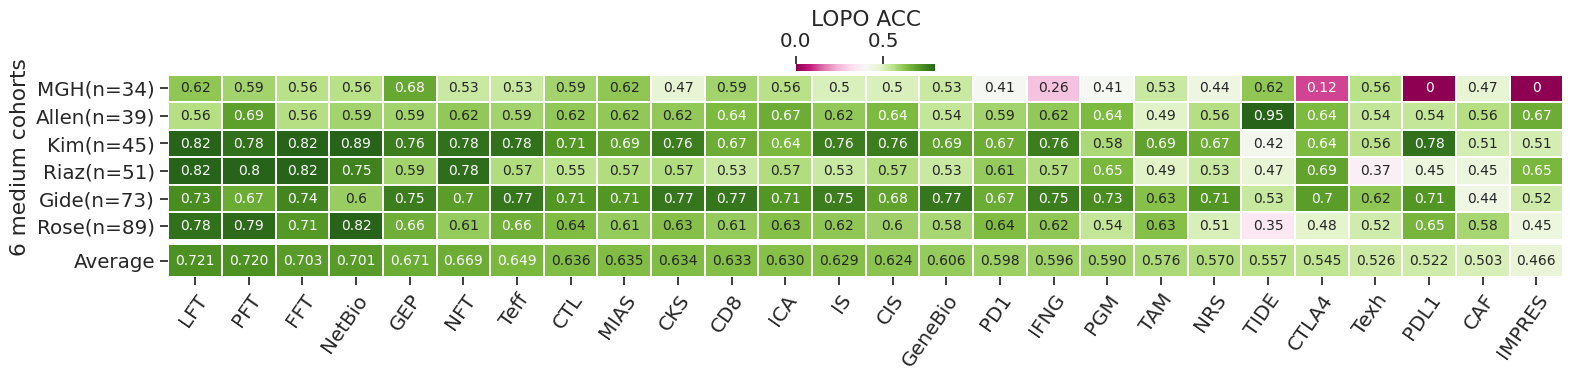

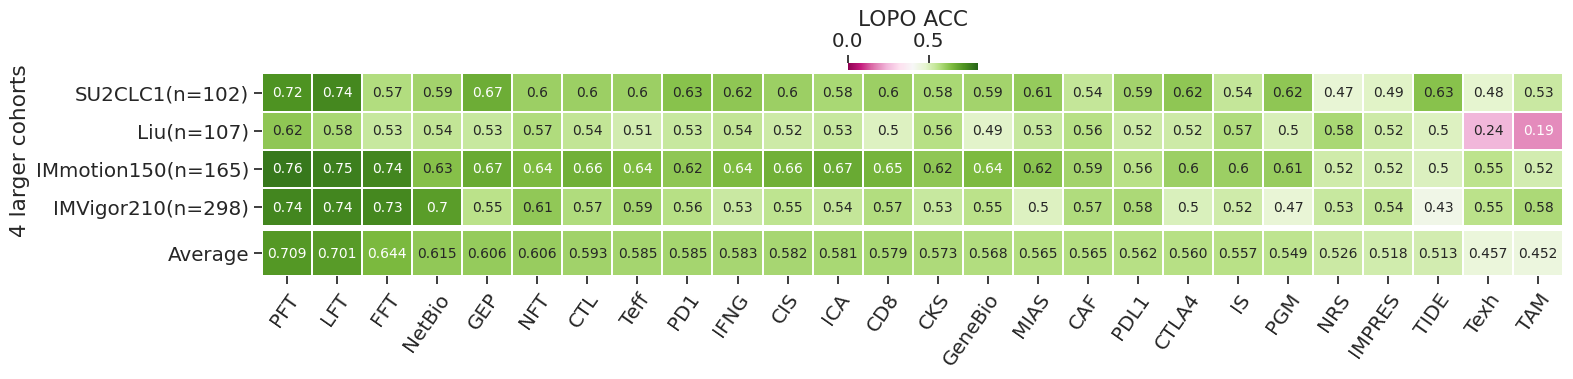

In [56]:
values = 'ACC'
    
cmap = 'PiYG' #PRGn PuOr
vmax = 0.8
vmin = 0.0

for s, label in zip(['small', 'medium', 'large'], labels):


    dfp1 = dfp[dfp['size_map'] == s]
    dfp1['cohort_name'] = dfp1['cohort'].apply(lambda x:x.replace('\n', ''))
    
    y_order = dfp1.sort_values('size')['cohort_name'].unique()
    data2d = pd.pivot_table(dfp1, index='mode', columns = 'cohort_name', values = values)
    modes = dfp1.groupby('mode')[values].mean().sort_values(ascending=False).index.to_list()
    data2d = data2d[y_order]
    data2d = data2d.loc[modes].T

    
    fig,axes = plt.subplots(figsize=(16, 4), nrows=2, height_ratios = [len(y_order), 1], sharex=True)
    ax1, ax2 = axes  

    cbar_kws=dict(location="top",pad=0.02,shrink=0.1, label = 'LOPO %s' % values)
    sns.heatmap(data2d, cmap = cmap, vmax = vmax, vmin = vmin, ax=ax1, cbar_kws = cbar_kws,
                    linewidths = 0.1, annot=True, annot_kws = {'fontsize':10})
    
    sns.heatmap(data2d.mean().to_frame(name='Average').T, 
                cmap = cmap, vmax = vmax, vmin = vmin,
                ax=ax2, annot=True, linewidths=.1,fmt='.3f',
                 annot_kws={"fontsize":10}, cbar=False)
    
    ax1.set_xlabel('')
    ax1.set_ylabel(label)
    
    ax2.tick_params(axis='both', which='major', right = False, top=False, direction = 'out',reset = True)
    ax1.tick_params(axis='y', which='major', right = False, top=False, direction = 'out',reset = True)
    
    ax2.set_xticklabels(
        modes, 
        rotation=55, 
        ha="right",  
        rotation_mode="anchor")  # <====== HERE is the ke
    
    #plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.06, hspace=None)
    ax2.set_xlabel('')
    
    fig.tight_layout(h_pad = 0.2)
    #fig.savefig('./results/%s_%s.pdf' % (values, s), bbox_inches = 'tight', dpi=96 )
    fig.savefig('./results/%s_%s.svg' % (values, s), bbox_inches = 'tight', dpi=96 )

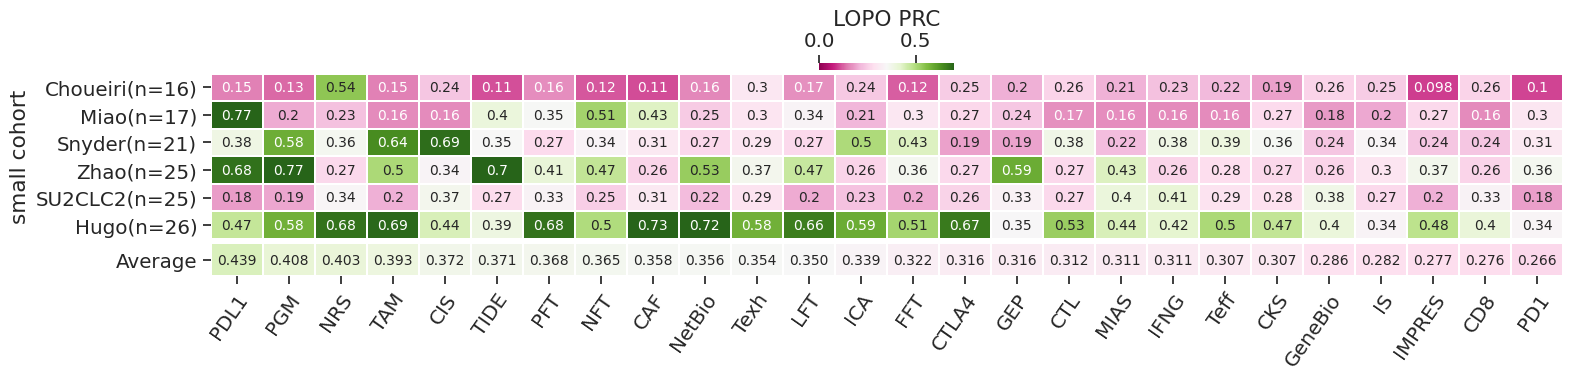

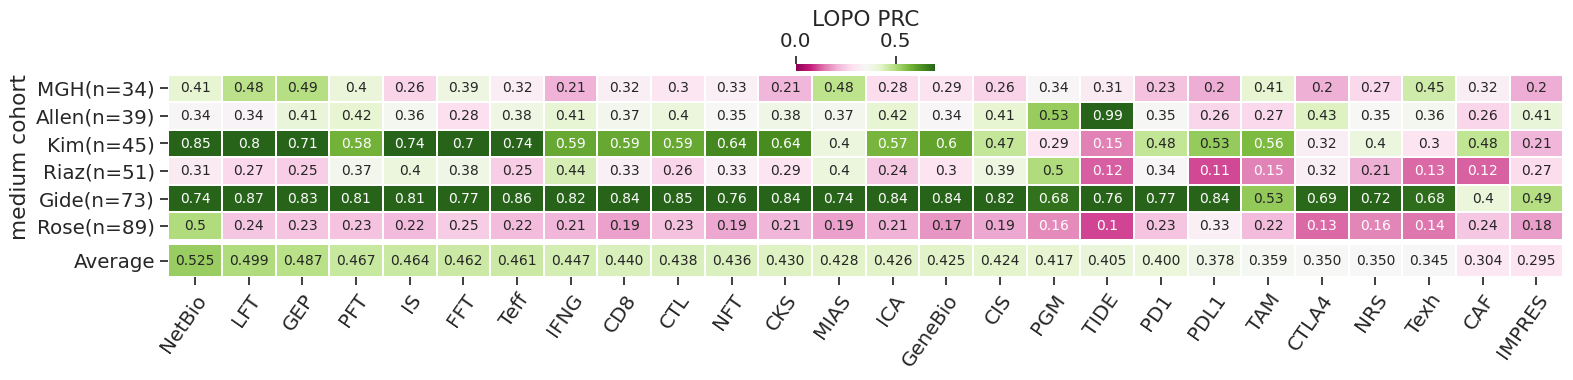

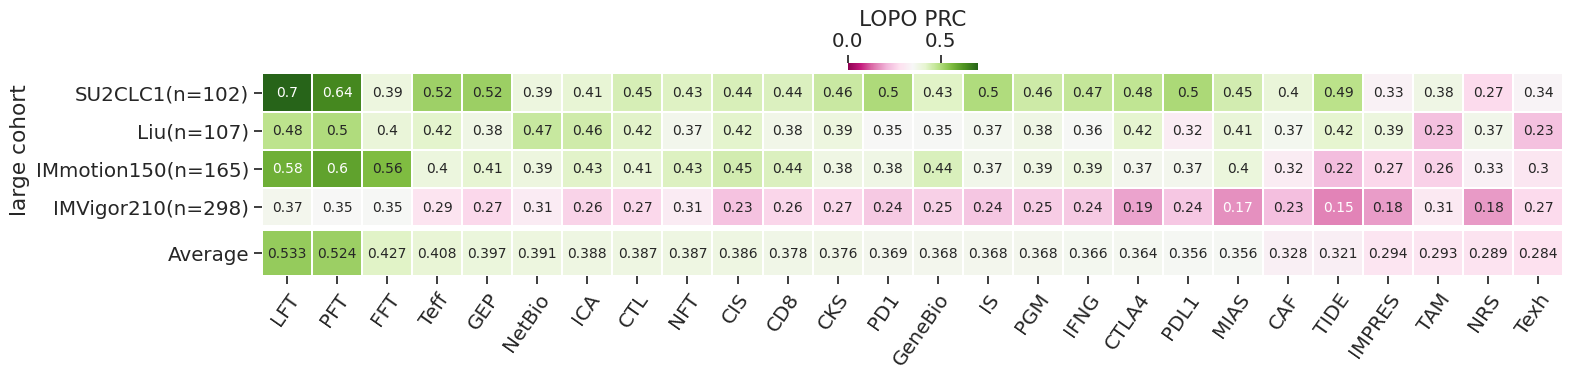

In [57]:
values = 'PRC'

cmap = 'PiYG' #PRGn PuOr
vmax = 0.7
vmin = 0.0

for s in ['small', 'medium', 'large']:

    dfp1 = dfp[dfp['size_map'] == s]
    dfp1['cohort_name'] = dfp1['cohort'].apply(lambda x:x.replace('\n', ''))
    
    y_order = dfp1.sort_values('size')['cohort_name'].unique()
    data2d = pd.pivot_table(dfp1, index='mode', columns = 'cohort_name', values = values)
    modes = dfp1.groupby('mode')[values].mean().sort_values(ascending=False).index.to_list()
    data2d = data2d[y_order]
    data2d = data2d.loc[modes].T

    
    fig,axes = plt.subplots(figsize=(16, 4), nrows=2, height_ratios = [len(y_order), 1], sharex=True)
    ax1, ax2 = axes  

    cbar_kws=dict(location="top",pad=0.02,shrink=0.1, label = 'LOPO %s' % values)
    sns.heatmap(data2d, cmap = cmap, vmax = vmax, vmin = vmin, ax=ax1, cbar_kws = cbar_kws,  
                    linewidths = 0.1, annot=True, annot_kws = {'fontsize':10})
    
    sns.heatmap(data2d.mean().to_frame(name='Average').T, 
                
                cmap = cmap, vmax = vmax, vmin = vmin,
                ax=ax2, annot=True, linewidths=.1,fmt='.3f',
                 annot_kws={"fontsize":10}, cbar=False)
    
    ax1.set_xlabel('')
    ax1.set_ylabel('%s cohort' % s)
        
    ax2.tick_params(axis='both', which='major', right = False, top=False, direction = 'out',reset = True)
    ax1.tick_params(axis='y', which='major', right = False, top=False, direction = 'out',reset = True)
    
    ax2.set_xticklabels(
        modes, 
        rotation=55, 
        ha="right",  
        rotation_mode="anchor")  # <====== HERE is the ke
    
    #plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.06, hspace=None)
    ax2.set_xlabel('')
    
    fig.tight_layout(h_pad = 0.2)
    #fig.savefig('./results/%s_%s.pdf' % (values, s), bbox_inches = 'tight', dpi=96 )
    fig.savefig('./results/%s_%s.svg' % (values, s), bbox_inches = 'tight', dpi=96 )

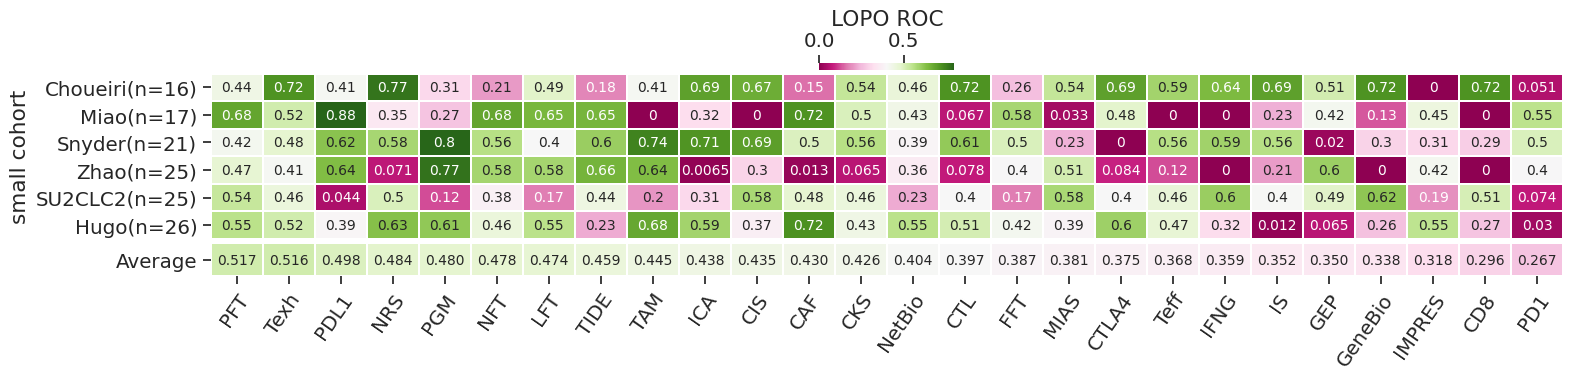

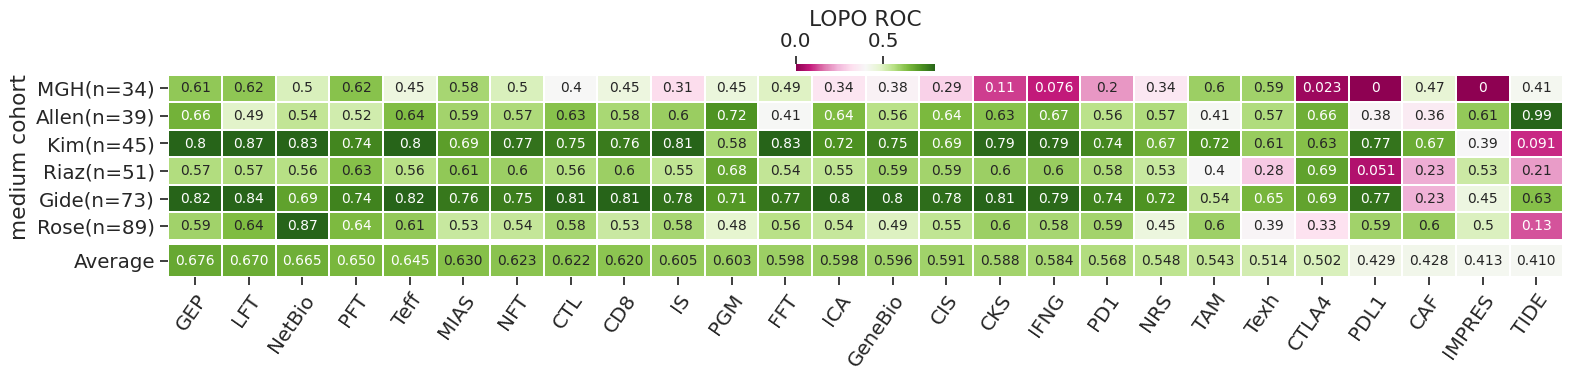

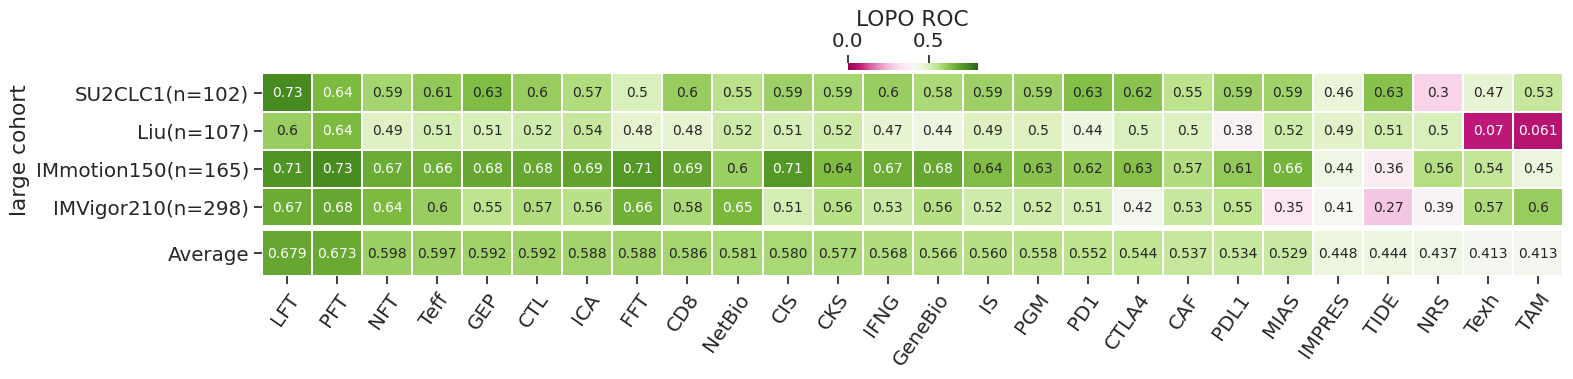

In [58]:
values = 'ROC'
    
cmap = 'PiYG' #PRGn PuOr
vmax = 0.8
vmin = 0.0

for s in ['small', 'medium', 'large']:

    dfp1 = dfp[dfp['size_map'] == s]
    dfp1['cohort_name'] = dfp1['cohort'].apply(lambda x:x.replace('\n', ''))
    
    y_order = dfp1.sort_values('size')['cohort_name'].unique()
    data2d = pd.pivot_table(dfp1, index='mode', columns = 'cohort_name', values = values)
    modes = dfp1.groupby('mode')[values].mean().sort_values(ascending=False).index.to_list()
    data2d = data2d[y_order]
    data2d = data2d.loc[modes].T

    
    fig,axes = plt.subplots(figsize=(16, 4), nrows=2, height_ratios = [len(y_order), 1], sharex=True)
    ax1, ax2 = axes  

    cbar_kws=dict(location="top",pad=0.02,shrink=0.1, label = 'LOPO %s' % values)
    sns.heatmap(data2d, cmap = cmap, vmax = vmax, vmin = vmin, ax=ax1, cbar_kws = cbar_kws,
                    linewidths = 0.1, annot=True, annot_kws = {'fontsize':10})
    
    
    sns.heatmap(data2d.mean().to_frame(name='Average').T, 
                
                cmap = cmap, vmax = vmax, vmin = vmin,
                ax=ax2, annot=True, linewidths=.1,fmt='.3f',
                 annot_kws={"fontsize":10}, cbar=False)
    
    ax1.set_xlabel('')
    ax1.set_ylabel('%s cohort' % s)

    ax2.tick_params(axis='both', which='major', right = False, top=False, direction = 'out',reset = True)
    ax1.tick_params(axis='y', which='major', right = False, top=False, direction = 'out',reset = True)
    
    ax2.set_xticklabels(
        modes, 
        rotation=55, 
        ha="right",  
        rotation_mode="anchor")  # <====== HERE is the ke
    
    #plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.06, hspace=None)
    ax2.set_xlabel('')
    
    fig.tight_layout(h_pad = 0.2)
    #fig.savefig('./results/%s_%s.pdf' % (values, s), bbox_inches = 'tight', dpi=96 )
    fig.savefig('./results/%s_%s.svg' % (values, s), bbox_inches = 'tight', dpi=96 )

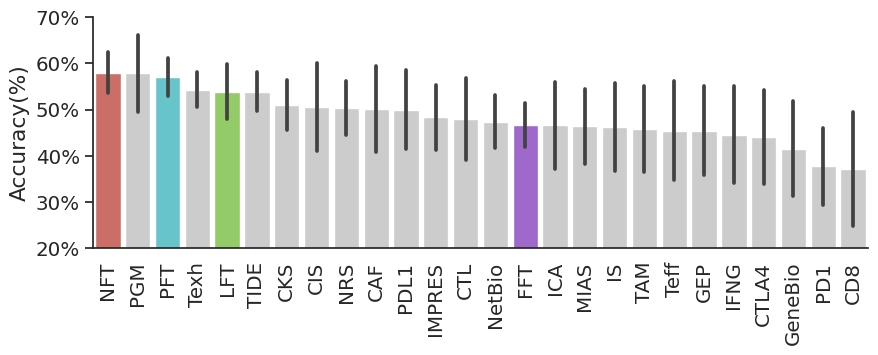

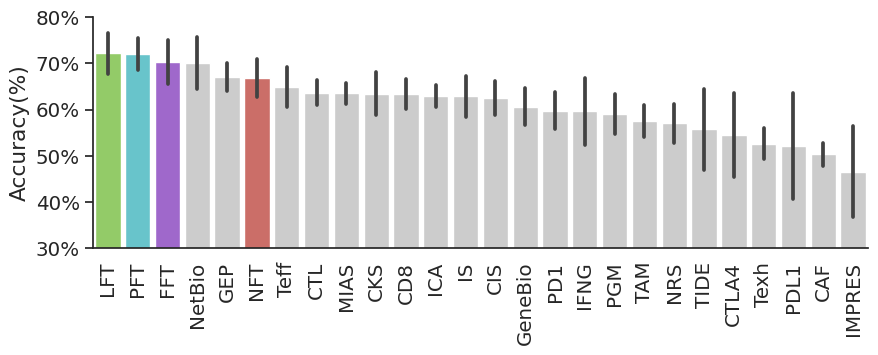

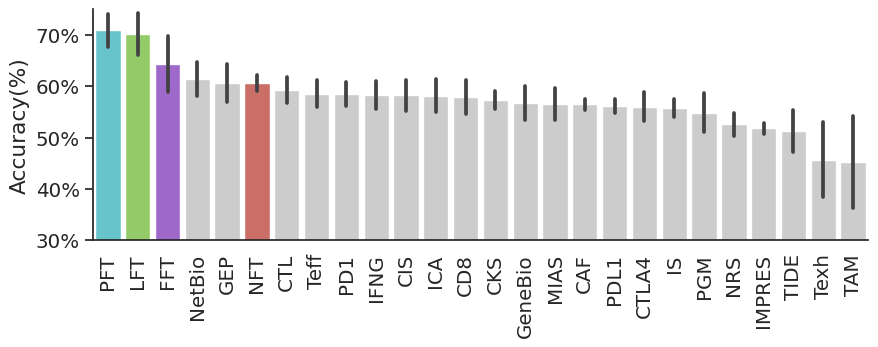

In [63]:
ot = '#cccccc'
f4 = sns.palettes.color_palette('hls', 4, desat = 1).as_hex()

mode_palette = { 'NFT':f4[0],'LFT':f4[1],  'PFT':f4[2], 'FFT':f4[3],
                'CKS':ot, 'GEP':ot,  'MIAS':ot,'PDL1':ot,
                'Teff':ot, 'GeneBio':ot,
                'TIDE':ot, 'TAM':ot, 'Texh':ot, 'CAF':ot, 'NRS':ot, 'CTLA4':ot, 'IMPRES':ot, 'PGM':ot,
                'PD1':ot,  'NetBio':ot, 
                'CD8':ot, 'IS':ot, 'IFNG':ot, 'ICA':ot, 'CTL':ot, 'CIS':ot, '42':ot,
                }

values = 'ACC'
for s, ylim in zip(['small', 'medium', 'large'], [(0.20, 0.70), (0.3, 0.80), (0.3, 0.75)]):

    dfp1 = dfp[dfp['size_map'] == s]
    dfp1['cohort_name'] = dfp1['cohort'].apply(lambda x:x.replace('\n', ''))

    fig,ax = plt.subplots(figsize=(10, 3), nrows=1, )
    order = dfp1.groupby('mode')[values].mean().sort_values(ascending=False).index.to_list()
    sns.barplot(data = dfp1, x='mode', y = values, order = order,width = 0.85, 
                errorbar = 'se', ax=ax, palette=mode_palette)
    #sns.swarmplot(data = dfp1, x='mode', y =values, order = order,ax=ax)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(ylim[0], ylim[1])
    ax.set_ylabel('Accuracy(%)')
    vals = ax.get_yticks()
    ax.set_yticklabels(['{:,.0%}'.format(x) for x in vals[:]])
    ax.tick_params(axis='y', which='major', right = False, top=False, direction = 'out',reset = True)
    
    ax.set_xticklabels(
    order, 
    rotation=90)  # <====== HERE is the ke

    ax.set_xlabel('')
    fig.savefig('./results/bar_%s_%s.svg' % (values, s), bbox_inches = 'tight', dpi= 96 )

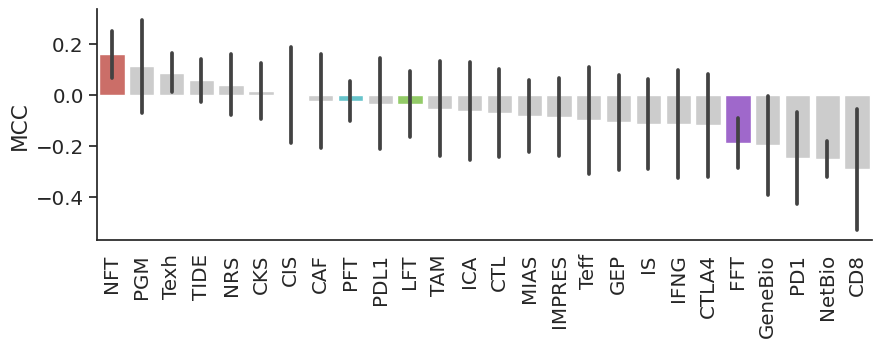

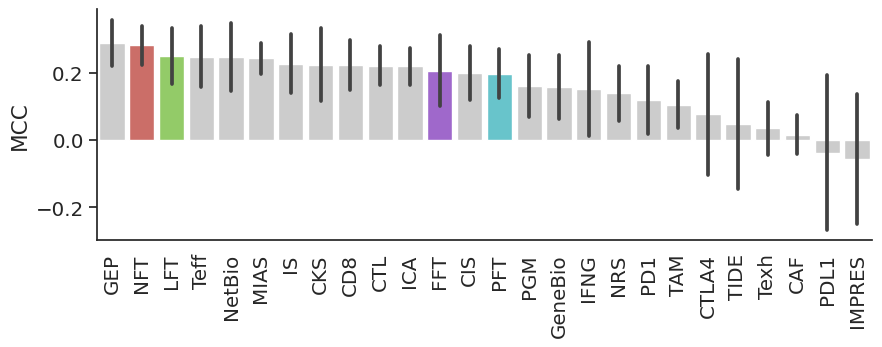

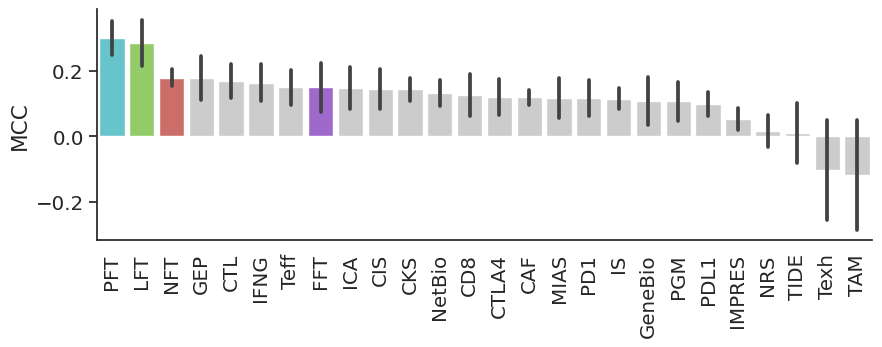

In [60]:
ot = '#cccccc'
f4 = sns.palettes.color_palette('hls', 4, desat = 1).as_hex()

mode_palette = { 'NFT':f4[0],'LFT':f4[1],  'PFT':f4[2], 'FFT':f4[3],
                'CKS':ot, 'GEP':ot,  'MIAS':ot,'PDL1':ot,
                'Teff':ot, 'GeneBio':ot,
                'TIDE':ot, 'TAM':ot, 'Texh':ot, 'CAF':ot, 'NRS':ot, 'CTLA4':ot, 'IMPRES':ot, 'PGM':ot,
                'PD1':ot,  'NetBio':ot, 
                'CD8':ot, 'IS':ot, 'IFNG':ot, 'ICA':ot, 'CTL':ot, 'CIS':ot, '42':ot,
                }

values = 'MCC'
for s, ylim in zip(['small', 'medium', 'large'], [(0.20, 0.70), (0.3, 0.80), (0.3, 0.75)]):

    dfp1 = dfp[dfp['size_map'] == s]
    dfp1['cohort_name'] = dfp1['cohort'].apply(lambda x:x.replace('\n', ''))

    fig,ax = plt.subplots(figsize=(10, 3), nrows=1, )
    order = dfp1.groupby('mode')[values].mean().sort_values(ascending=False).index.to_list()
    sns.barplot(data = dfp1, x='mode', y = values, order = order,width = 0.85, 
                errorbar = 'se', ax=ax, palette=mode_palette)
    #sns.swarmplot(data = dfp1, x='mode', y =values, order = order,ax=ax)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    #ax.set_ylim(ylim[0], ylim[1])
    # ax.set_ylabel('Accuracy(%)')
    # vals = ax.get_yticks()
    # ax.set_yticklabels(['{:,.0%}'.format(x) for x in vals[:]])
    ax.tick_params(axis='y', which='major', right = False, top=False, direction = 'out',reset = True)
    
    ax.set_xticklabels(
    order, 
    rotation=90)  # <====== HERE is the ke

    ax.set_xlabel('')
    fig.savefig('./results/bar_%s_%s.svg' % (values, s), bbox_inches = 'tight', dpi= 96 )

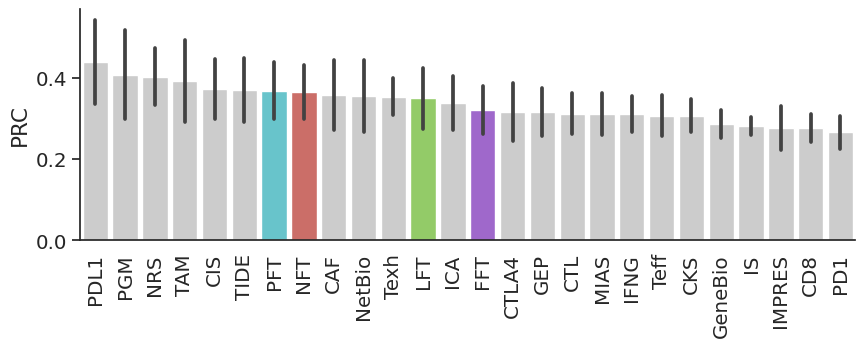

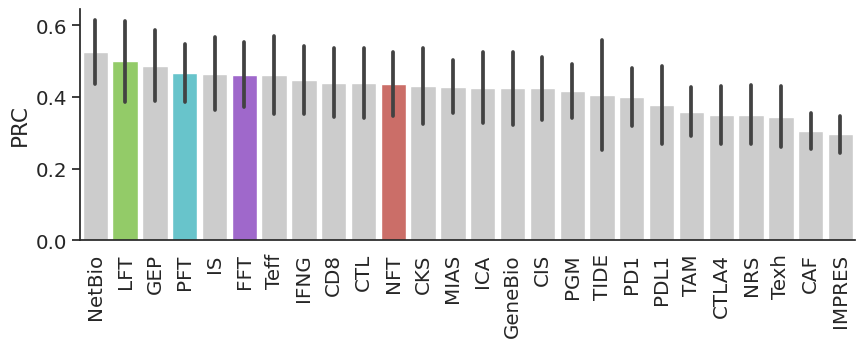

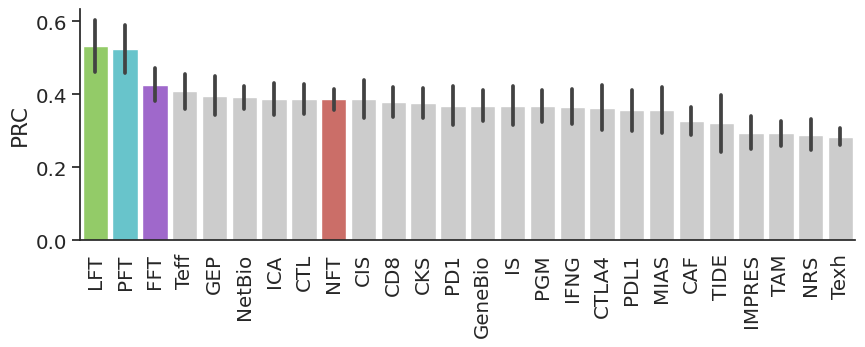

In [61]:
ot = '#cccccc'
f4 = sns.palettes.color_palette('hls', 4, desat = 1).as_hex()

mode_palette = { 'NFT':f4[0],'LFT':f4[1],  'PFT':f4[2], 'FFT':f4[3],
                'CKS':ot, 'GEP':ot,  'MIAS':ot,'PDL1':ot,
                'Teff':ot, 'GeneBio':ot,
                'TIDE':ot, 'TAM':ot, 'Texh':ot, 'CAF':ot, 'NRS':ot, 'CTLA4':ot, 'IMPRES':ot, 'PGM':ot,
                'PD1':ot,  'NetBio':ot, 
                'CD8':ot, 'IS':ot, 'IFNG':ot, 'ICA':ot, 'CTL':ot, 'CIS':ot, '42':ot,
                }

values = 'PRC'
for s, ylim in zip(['small', 'medium', 'large'], [(0.20, 0.70), (0.3, 0.80), (0.3, 0.75)]):

    dfp1 = dfp[dfp['size_map'] == s]
    dfp1['cohort_name'] = dfp1['cohort'].apply(lambda x:x.replace('\n', ''))

    fig,ax = plt.subplots(figsize=(10, 3), nrows=1, )
    order = dfp1.groupby('mode')[values].mean().sort_values(ascending=False).index.to_list()
    sns.barplot(data = dfp1, x='mode', y = values, order = order,width = 0.85, 
                errorbar = 'se', ax=ax, palette=mode_palette)
    #sns.swarmplot(data = dfp1, x='mode', y =values, order = order,ax=ax)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    #ax.set_ylim(ylim[0], ylim[1])
    # ax.set_ylabel('Accuracy(%)')
    # vals = ax.get_yticks()
    # ax.set_yticklabels(['{:,.0%}'.format(x) for x in vals[:]])
    ax.tick_params(axis='y', which='major', right = False, top=False, direction = 'out',reset = True)
    
    ax.set_xticklabels(
    order, 
    rotation=90)  # <====== HERE is the ke

    ax.set_xlabel('')
    fig.savefig('./results/bar_%s_%s.svg' % (values, s), bbox_inches = 'tight', dpi= 96 )

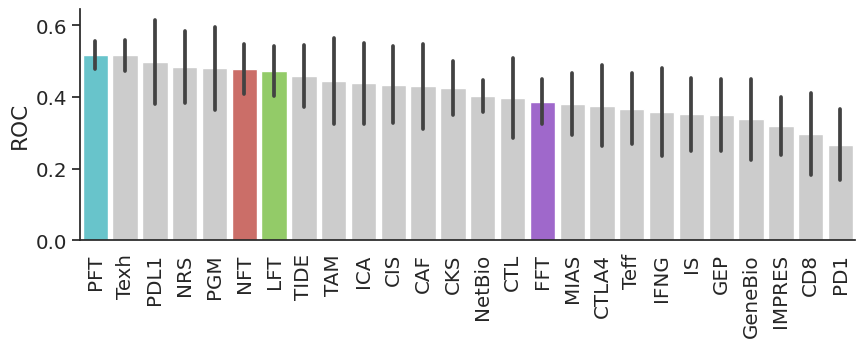

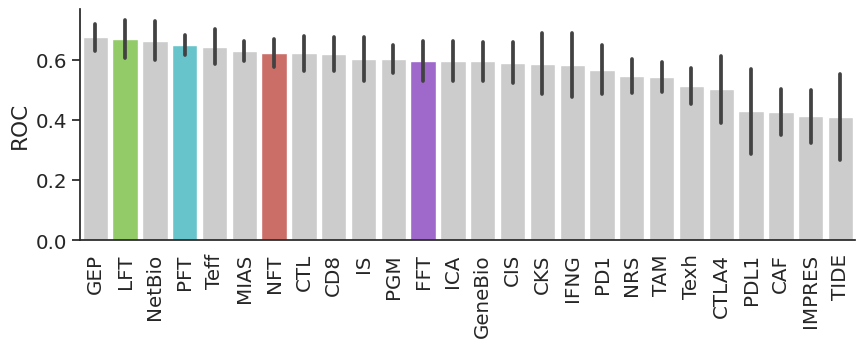

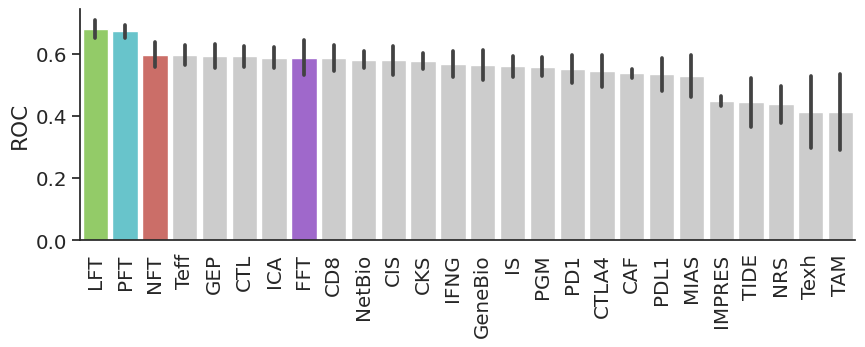

In [62]:
ot = '#cccccc'
f4 = sns.palettes.color_palette('hls', 4, desat = 1).as_hex()

mode_palette = { 'NFT':f4[0],'LFT':f4[1],  'PFT':f4[2], 'FFT':f4[3],
                'CKS':ot, 'GEP':ot,  'MIAS':ot,'PDL1':ot,
                'Teff':ot, 'GeneBio':ot,
                'TIDE':ot, 'TAM':ot, 'Texh':ot, 'CAF':ot, 'NRS':ot, 'CTLA4':ot, 'IMPRES':ot, 'PGM':ot,
                'PD1':ot,  'NetBio':ot, 
                'CD8':ot, 'IS':ot, 'IFNG':ot, 'ICA':ot, 'CTL':ot, 'CIS':ot, '42':ot,
                }

values = 'ROC'
for s, ylim in zip(['small', 'medium', 'large'], [(0.20, 0.70), (0.3, 0.80), (0.3, 0.75)]):

    dfp1 = dfp[dfp['size_map'] == s]
    dfp1['cohort_name'] = dfp1['cohort'].apply(lambda x:x.replace('\n', ''))

    fig,ax = plt.subplots(figsize=(10, 3), nrows=1, )
    order = dfp1.groupby('mode')[values].mean().sort_values(ascending=False).index.to_list()
    sns.barplot(data = dfp1, x='mode', y = values, order = order,width = 0.85, 
                errorbar = 'se', ax=ax, palette=mode_palette)
    #sns.swarmplot(data = dfp1, x='mode', y =values, order = order,ax=ax)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    #ax.set_ylim(ylim[0], ylim[1])
    # ax.set_ylabel('Accuracy(%)')
    # vals = ax.get_yticks()
    # ax.set_yticklabels(['{:,.0%}'.format(x) for x in vals[:]])
    ax.tick_params(axis='y', which='major', right = False, top=False, direction = 'out',reset = True)
    
    ax.set_xticklabels(
    order, 
    rotation=90)  # <====== HERE is the ke

    ax.set_xlabel('')
    fig.savefig('./results/bar_%s_%s.svg' % (values, s), bbox_inches = 'tight', dpi= 96 )